# PHASE 1 — Problem Definition


In [94]:
# Target variable: SeriousDlqin2yrs
#   = 1 → borrower defaults (90+ days past due within 2 years)
#   = 0 → borrower remains good
#
# Model: Logistic Regression with WOE-transformed features
# Evaluation: AUC, KS statistic, Lift/Gains charts
# Output: Scorecard for approve / review / reject decisions

# PHASE 2 — Data Loading & Initial Inspection

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
import warnings
warnings.filterwarnings('ignore')


In [96]:
df = pd.read_csv("/content/cs-training.csv")

In [97]:
!pip install xlrd)

/bin/bash: -c: line 1: syntax error near unexpected token `)'
/bin/bash: -c: line 1: `pip install xlrd)'


In [98]:
# Load data dictionary (requires xlrd: pip install xlrd)
pd.set_option('display.max_colwidth', None)
file_path = "/content/Data Dictionary.xls"
data = pd.read_excel(file_path, header=None)
data.columns = data.iloc[0]
data = data[1:].reset_index(drop=True)
data.columns = data.columns.str.strip()



In [99]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [100]:
df.head()


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [101]:
df.duplicated().sum()


np.int64(0)

In [102]:
df.isnull().sum()


,0
Unnamed: 0,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,29731
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0


In [103]:

df = df.drop('Unnamed: 0', axis=1)

# PHASE 3 — Train/Test Split (EARLY — Critical for no data leakage)


In [104]:
y = df["SeriousDlqin2yrs"]
X = df.drop(columns=["SeriousDlqin2yrs"])


In [105]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # preserves class ratio in both splits
)

# PHASE 4 — Target Variable Analysis

In [106]:

def analyze_target_classification(y_series, label=""):
    """
    Analyze class distribution and imbalance for a binary target.

    Parameters
    ----------
    y_series : pd.Series  Binary target (0/1)
    label    : str        Display label for context (e.g. "train", "test")
    """
    class_counts      = y_series.value_counts()
    class_percentages = y_series.value_counts(normalize=True) * 100

    header = f"TARGET CLASS DISTRIBUTION{' (' + label + ')' if label else ''}"
    print(f"\n{'='*50}")
    print(header)
    print('='*50)
    for cls in class_counts.index:
        print(f"  Class {cls}: {class_counts[cls]:>6} samples  ({class_percentages[cls]:.2f}%)")

    # Visualise
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(class_counts.index.astype(str), class_counts.values,
                color=['steelblue', 'tomato'])
    axes[0].set_title(f'Class Distribution — {label}')
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Count')

    axes[1].pie(class_counts.values,
                labels=class_counts.index.astype(str),
                autopct='%1.1f%%',
                colors=['steelblue', 'tomato'])
    axes[1].set_title(f'Class Proportions — {label}')
    plt.tight_layout()
    plt.show()

    imbalance_ratio = class_percentages.max() / class_percentages.min()
    print(f"\n  Minority class : {class_percentages.min():.2f}%")
    print(f"  Majority class : {class_percentages.max():.2f}%")
    print(f"  Imbalance ratio: {imbalance_ratio:.2f}:1")

    if imbalance_ratio < 2:
        print("  ✓ Balanced — standard logistic regression works well")
    elif imbalance_ratio < 5:
        print("  ⚠ Moderately imbalanced — consider class_weight='balanced'")
    else:
        print("  ❗ Severely imbalanced — use class weights or sampling")

    return class_counts, class_percentages, imbalance_ratio

In [107]:
y_train.isnull().sum()   # check no missing in target

np.int64(0)


TARGET CLASS DISTRIBUTION (train)
  Class 0: 111979 samples  (93.32%)
  Class 1:   8021 samples  (6.68%)


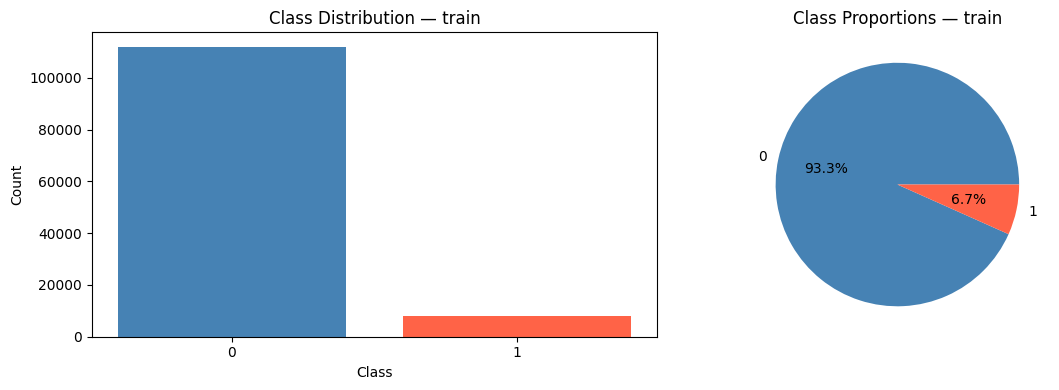


  Minority class : 6.68%
  Majority class : 93.32%
  Imbalance ratio: 13.96:1
  ❗ Severely imbalanced — use class weights or sampling

TARGET CLASS DISTRIBUTION (test)
  Class 0:  27995 samples  (93.32%)
  Class 1:   2005 samples  (6.68%)


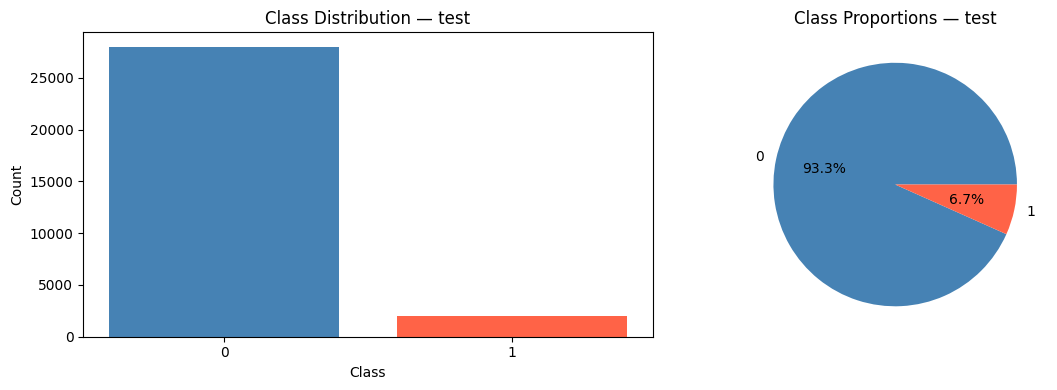


  Minority class : 6.68%
  Majority class : 93.32%
  Imbalance ratio: 13.96:1
  ❗ Severely imbalanced — use class weights or sampling


(SeriousDlqin2yrs
 0    27995
 1     2005
 Name: count, dtype: int64,
 SeriousDlqin2yrs
 0    93.316667
 1     6.683333
 Name: proportion, dtype: float64,
 13.962593516209477)

In [108]:
class_counts, class_percentages, imbalance_ratio = analyze_target_classification(y_train, "train")
analyze_target_classification(y_test, "test")

In [109]:
y_train.value_counts(normalize=True)

,proportion
SeriousDlqin2yrs,
0,0.933158
1,0.066842


In [110]:
# Decision: use class_weight='balanced' in LogisticRegression to handle imbalance
# without distorting the underlying probability distribution.

# PHASE 5 — Feature Exploration (TRAIN ONLY — no test contamination)

In [111]:
X_train.columns = X_train.columns.str.lower()
X_test.columns  = X_test.columns.str.lower()

In [112]:
missing_info = X_train.isnull().mean() * 100
print("Missing values > 0%:\n", missing_info[missing_info > 0])

Missing values > 0%:
 monthlyincome         19.729167
numberofdependents     2.606667
dtype: float64


In [113]:
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols     = X_train.select_dtypes(include='object').columns.tolist()
print(f"\nNumeric features  : {len(numeric_cols)}")
print(f"Categorical features: {len(cat_cols)}")


Numeric features  : 10
Categorical features: 0


In [114]:
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_train[numeric_cols].fillna(0))
low_var = [col for col, keep in zip(numeric_cols, vt.get_support()) if not keep]
print(f"\nNear-zero variance features: {low_var}")


Near-zero variance features: []


In [115]:
print("\nMissingness vs Target (chi-square p-values):")
for col in X_train.columns:
    if X_train[col].isnull().sum() > 0:
        missing_flag = X_train[col].isnull().astype(int)
        ct = pd.crosstab(missing_flag, y_train)
        if ct.shape == (2, 2):
            _, p, _, _ = chi2_contingency(ct)
            flag = "⚠ MNAR suspected" if p < 0.05 else "✓ OK"
            print(f"  {col}: p={p:.4f}  {flag}")


Missingness vs Target (chi-square p-values):
  monthlyincome: p=0.0000  ⚠ MNAR suspected
  numberofdependents: p=0.0000  ⚠ MNAR suspected


In [116]:
skew_values = X_train.apply(lambda x: skew(x.dropna()))
print("\nSkewness:\n", skew_values)


Skewness:
 revolvingutilizationofunsecuredlines    100.538203
age                                       0.186196
numberoftime30-59dayspastduenotworse     22.656445
debtratio                                99.142824
monthlyincome                           122.587602
numberofopencreditlinesandloans           1.228632
numberoftimes90dayslate                  23.155585
numberrealestateloansorlines              3.752641
numberoftime60-89dayspastduenotworse     23.393598
numberofdependents                        1.598556
dtype: float64


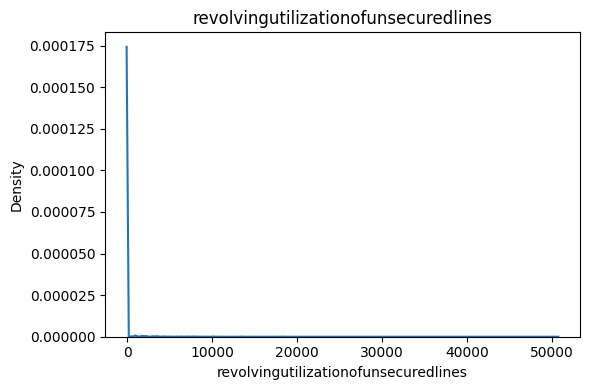

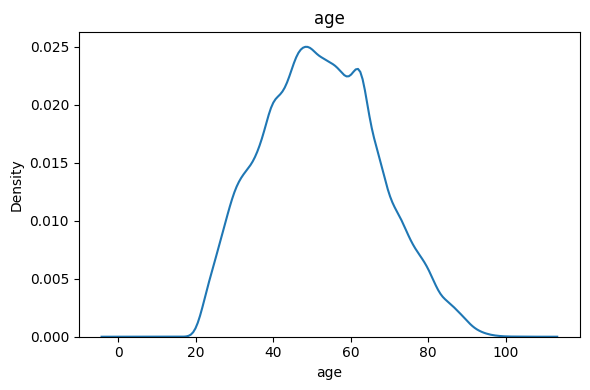

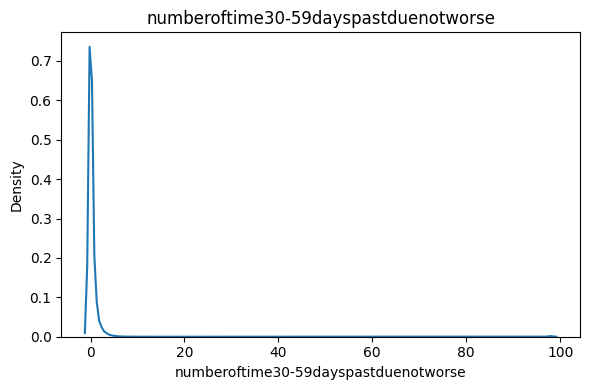

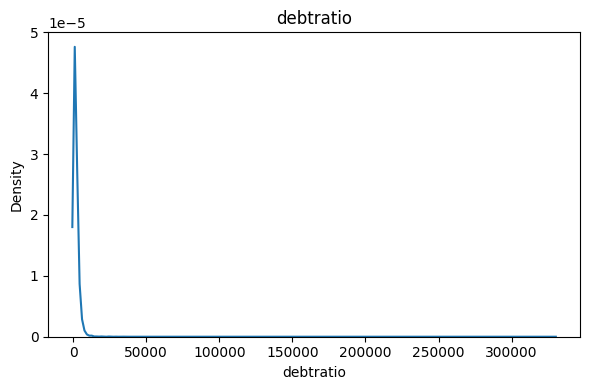

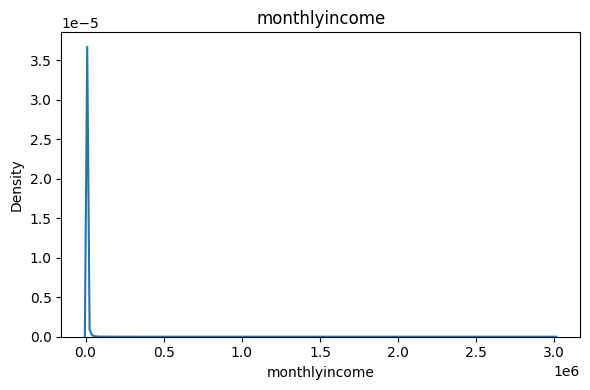

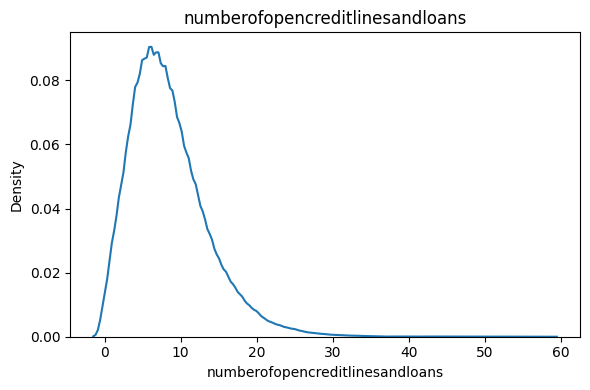

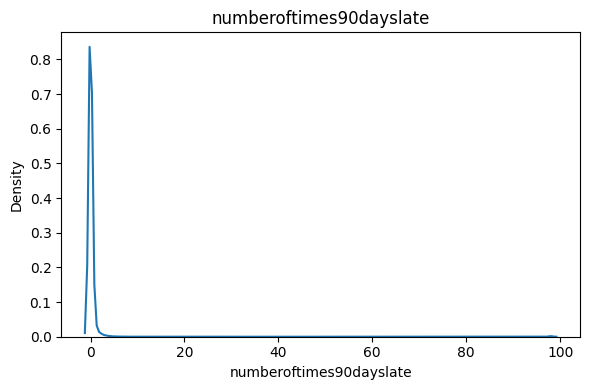

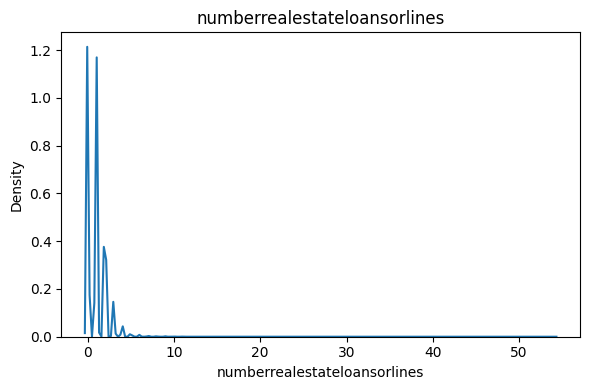

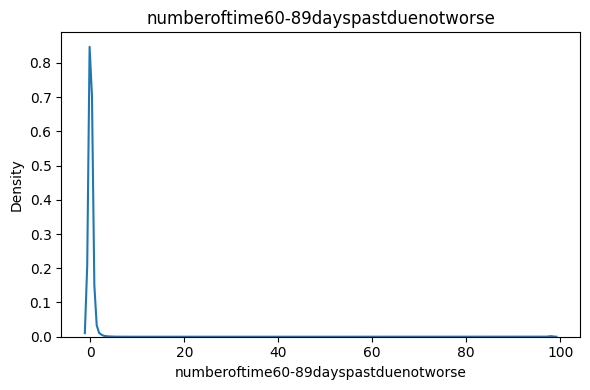

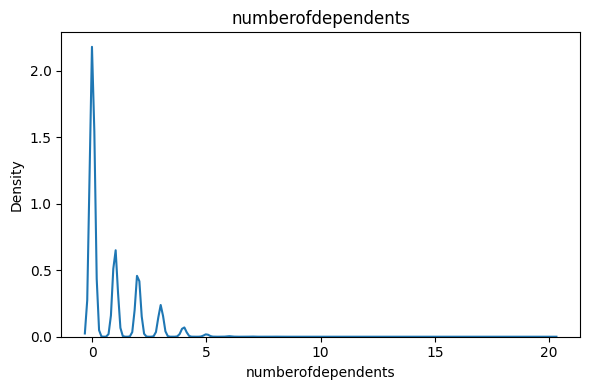

In [117]:
for col in X_train.columns:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(X_train[col].dropna())
    plt.title(col)
    plt.tight_layout()
    plt.show()


In [118]:

def analyze_feature_outliers_classification(X_train, y_train, column):
    """
    Outlier analysis with class-specific views for classification.

    Parameters
    ----------
    X_train : pd.DataFrame  Training features (columns already lowercased)
    y_train : pd.Series     Binary target
    column  : str           Column name (lowercase)
    """
    print(f"\n--- Outlier analysis: {column} ---")

    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    iqr_outliers = X_train[(X_train[column] < lower_bound) | (X_train[column] > upper_bound)]
    iqr_pct = len(iqr_outliers) / len(X_train) * 100
    print(f"  IQR outliers: {len(iqr_outliers)} ({iqr_pct:.2f}%)")
    print(f"  Bounds: [{lower_bound:.4f}, {upper_bound:.4f}]")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    classes = y_train.unique()
    data_to_plot = [X_train[y_train == cls][column].dropna() for cls in classes]
    axes[0].boxplot(data_to_plot, labels=[f'Class {c}' for c in classes])
    axes[0].set_title(f'{column} — Boxplot by Class')

    for cls in classes:
        axes[1].hist(X_train[y_train == cls][column].dropna(),
                     alpha=0.5, label=f'Class {cls}', bins=20)
    axes[1].set_title(f'{column} — Distribution by Class')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print("  Outlier rate by class:")
    for cls in classes:
        cls_data = X_train[y_train == cls][column]
        cls_out  = cls_data[(cls_data < lower_bound) | (cls_data > upper_bound)]
        print(f"    Class {cls}: {len(cls_out) / len(cls_data) * 100:.2f}%")

    return iqr_pct


--- Outlier analysis: revolvingutilizationofunsecuredlines ---
  IQR outliers: 617 (0.51%)
  Bounds: [-0.7628, 1.3502]


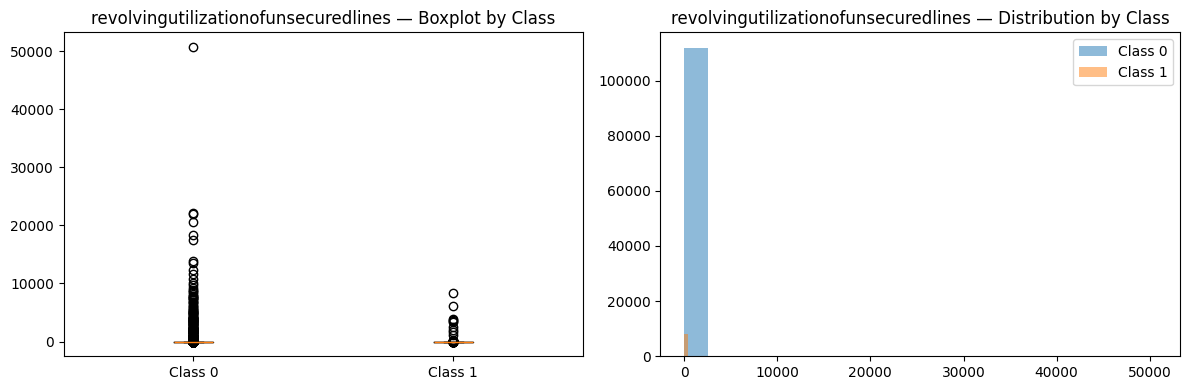

  Outlier rate by class:
    Class 0: 0.37%
    Class 1: 2.47%

--- Outlier analysis: age ---
  IQR outliers: 37 (0.03%)
  Bounds: [8.0000, 96.0000]


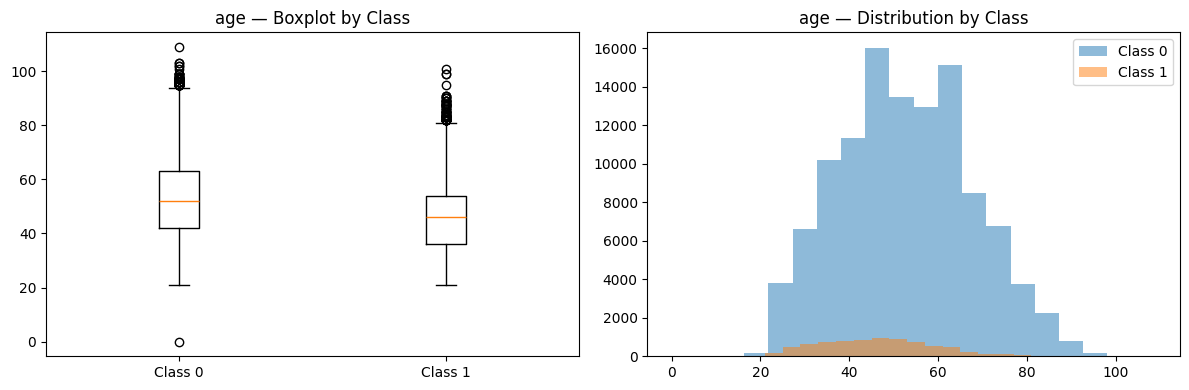

  Outlier rate by class:
    Class 0: 0.03%
    Class 1: 0.04%

--- Outlier analysis: numberoftime30-59dayspastduenotworse ---
  IQR outliers: 19206 (16.00%)
  Bounds: [0.0000, 0.0000]


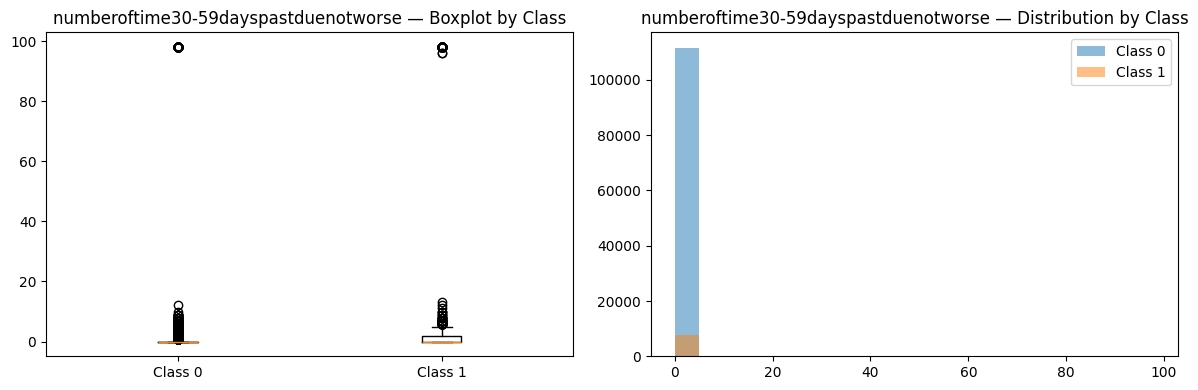

  Outlier rate by class:
    Class 0: 13.61%
    Class 1: 49.40%

--- Outlier analysis: debtratio ---
  IQR outliers: 24938 (20.78%)
  Bounds: [-0.8529, 1.8891]


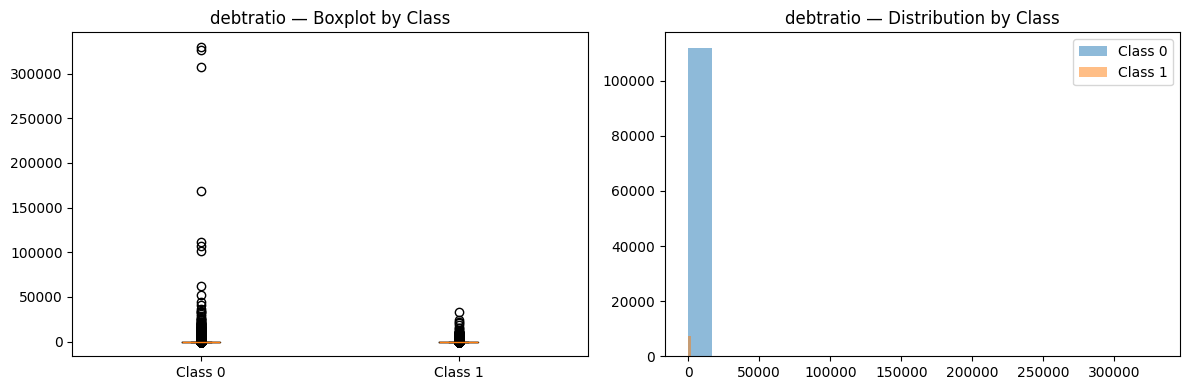

  Outlier rate by class:
    Class 0: 21.03%
    Class 1: 17.25%

--- Outlier analysis: monthlyincome ---
  IQR outliers: 3971 (3.31%)
  Bounds: [-3857.0000, 15495.0000]


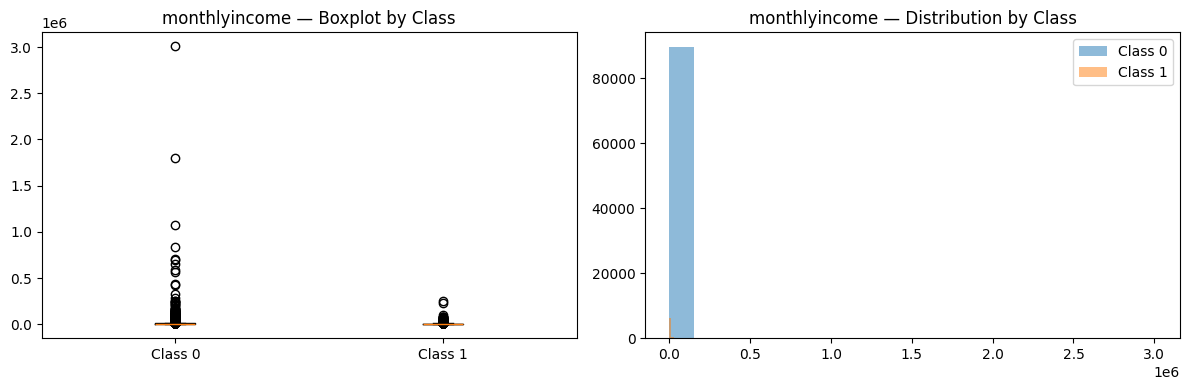

  Outlier rate by class:
    Class 0: 3.37%
    Class 1: 2.42%

--- Outlier analysis: numberofopencreditlinesandloans ---
  IQR outliers: 3195 (2.66%)
  Bounds: [-4.0000, 20.0000]


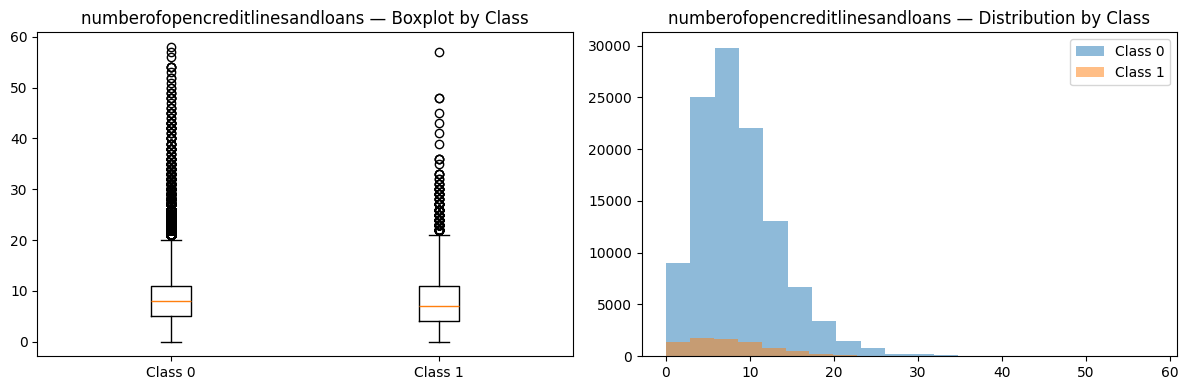

  Outlier rate by class:
    Class 0: 2.66%
    Class 1: 2.66%

--- Outlier analysis: numberoftimes90dayslate ---
  IQR outliers: 6706 (5.59%)
  Bounds: [0.0000, 0.0000]


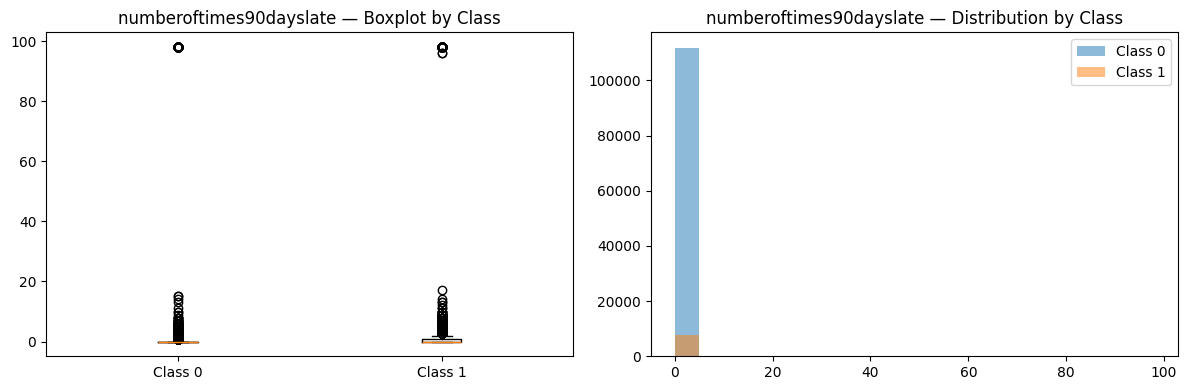

  Outlier rate by class:
    Class 0: 3.49%
    Class 1: 34.85%

--- Outlier analysis: numberrealestateloansorlines ---
  IQR outliers: 626 (0.52%)
  Bounds: [-3.0000, 5.0000]


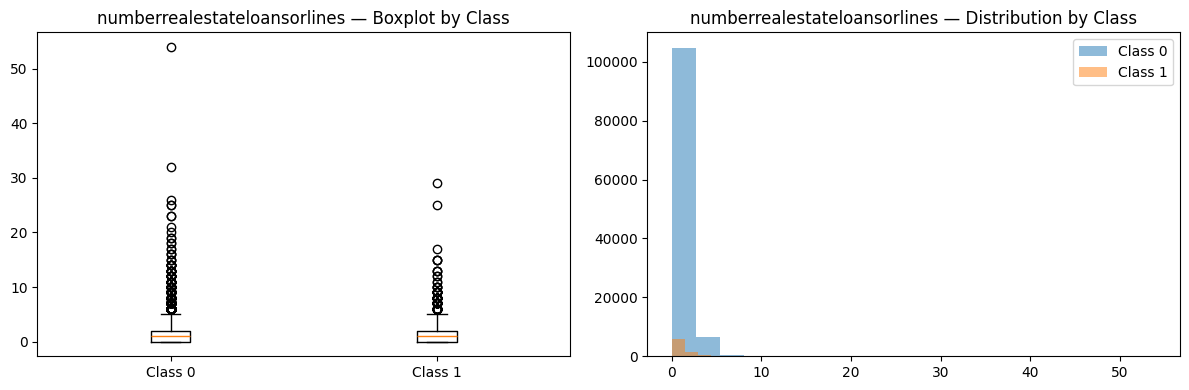

  Outlier rate by class:
    Class 0: 0.46%
    Class 1: 1.33%

--- Outlier analysis: numberoftime60-89dayspastduenotworse ---
  IQR outliers: 6119 (5.10%)
  Bounds: [0.0000, 0.0000]


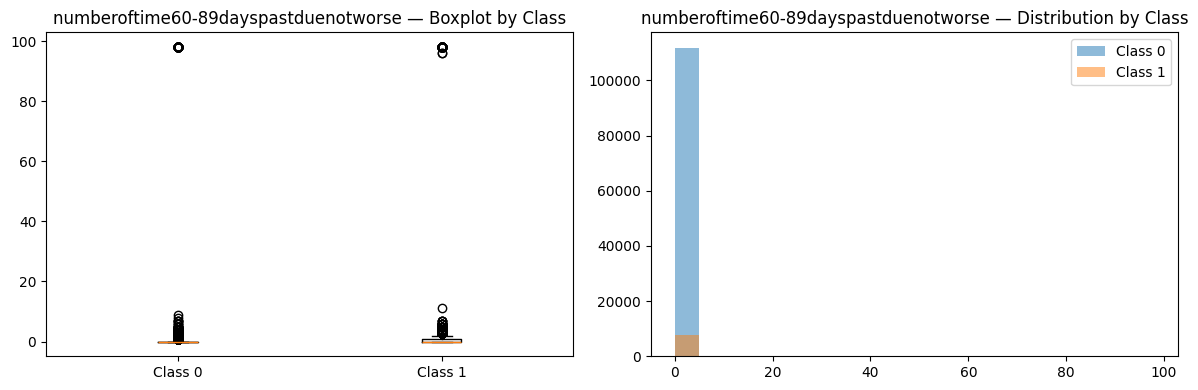

  Outlier rate by class:
    Class 0: 3.47%
    Class 1: 27.80%

--- Outlier analysis: numberofdependents ---
  IQR outliers: 10660 (8.88%)
  Bounds: [-1.5000, 2.5000]


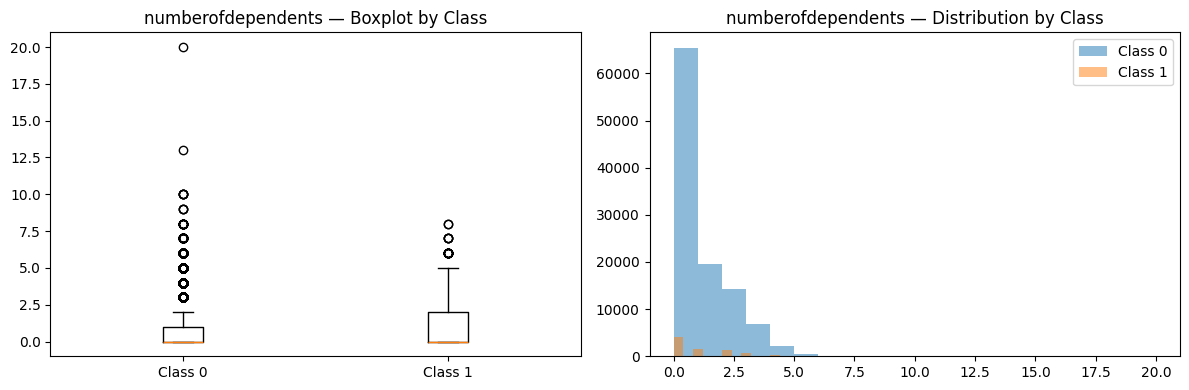

  Outlier rate by class:
    Class 0: 8.65%
    Class 1: 12.18%


In [119]:
for col in numeric_cols:
    # numeric_cols was built before rename, so refresh
    pass

numeric_cols_lower = X_train.select_dtypes(include=np.number).columns.tolist()
for col in numeric_cols_lower:
    analyze_feature_outliers_classification(X_train, y_train, col)

# PHASE 6 — Data Cleaning & Feature Engineering (PRE-WOE)

In [120]:
for col in ['monthlyincome', 'numberofdependents']:
    X_train[f'{col}_missing'] = X_train[col].isnull().astype(int)
    X_test[f'{col}_missing']  = X_test[col].isnull().astype(int)

In [121]:
income_median = X_train['monthlyincome'].median()
X_train['monthlyincome'] = X_train['monthlyincome'].fillna(income_median)
X_test['monthlyincome']  = X_test['monthlyincome'].fillna(income_median)

In [122]:
X_train['numberofdependents'] = X_train['numberofdependents'].fillna(0)
X_test['numberofdependents']  = X_test['numberofdependents'].fillna(0)

In [123]:
def feature_engineering(df):
    """
    Engineer credit-risk-relevant features from raw columns.

    Features:
    - total_delinquency  : sum of all delinquency buckets (strong default signal)
    - income_per_person  : monthly income per household member (debt capacity)
    - credit_stress      : utilization × debt ratio (combined stress indicator)
    """
    df = df.copy()  # BUG 8 FIX: avoid in-place mutation of the caller's DataFrame

    df['total_delinquency'] = (
        df['numberoftime30-59dayspastduenotworse']
        + df['numberoftime60-89dayspastduenotworse']
        + df['numberoftimes90dayslate']
    )

    df['income_per_person'] = df['monthlyincome'] / (df['numberofdependents'] + 1)

    df['credit_stress'] = (
        df['revolvingutilizationofunsecuredlines'] * df['debtratio']
    )

    return df

In [124]:
X_train = feature_engineering(X_train)
X_test  = feature_engineering(X_test)

In [125]:
def cap_outliers(df, cols, lower_q=0.01, upper_q=0.99):
    """
    Winsorise extreme values using train-computed quantile bounds.
    Applied to both train and test using TRAIN quantiles only.
    """
    bounds = {}
    df = df.copy()
    for col in cols:
        lower = df[col].quantile(lower_q)
        upper = df[col].quantile(upper_q)
        df[col] = df[col].clip(lower, upper)
        bounds[col] = (lower, upper)
    return df, bounds

In [126]:
num_cols_eng = X_train.select_dtypes(include='number').columns.tolist()
X_train, outlier_bounds = cap_outliers(X_train, num_cols_eng)

In [127]:
X_test_capped = X_test.copy()
for col, (lower, upper) in outlier_bounds.items():
    if col in X_test_capped.columns:
        X_test_capped[col] = X_test_capped[col].clip(lower, upper)
X_test = X_test_capped

# PHASE 7 — WOE Binning & Information Value

In [128]:
def create_woe_bins(df, feature, target, bins=None, n_bins=5,
                    max_woe=3.0, min_obs=50):
    """
    Compute WOE table and Information Value for one feature.

    BUG 5 FIX: Reduced min_obs default from 100 → 50 to avoid over-dropping
    bins on smaller datasets. Also stored bin EDGES (not Interval objects)
    to enable consistent pd.cut on unseen data.

    Parameters
    ----------
    df       : pd.DataFrame  Must contain feature and target columns
    feature  : str
    target   : str
    bins     : list or None  Custom cut edges (use for domain-specific bins)
    n_bins   : int           Quantile bins when bins=None
    max_woe  : float         WOE cap to prevent extreme values
    min_obs  : int           Minimum bin size (bins smaller than this are merged)

    Returns
    -------
    grouped  : pd.DataFrame  WOE table (total, bad, good, woe, iv per bin)
    iv_total : float         Information Value
    bin_edges: list          Bin cut edges for consistent test transformation
    """
    data = df[[feature, target]].copy()

    if bins is not None:
        data[f'{feature}_bin'] = pd.cut(data[feature], bins=bins, include_lowest=True)
        bin_edges = bins
    else:
        data[f'{feature}_bin'], retbins = pd.qcut(
            data[feature], q=n_bins, duplicates='drop', retbins=True
        )
        bin_edges = retbins.tolist()

    grouped = data.groupby(f'{feature}_bin', observed=True)[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'bad']
    grouped['good'] = grouped['total'] - grouped['bad']

    # Drop under-populated bins
    grouped = grouped[grouped['total'] >= min_obs]

    total_good = grouped['good'].sum()
    total_bad  = grouped['bad'].sum()

    if total_good == 0 or total_bad == 0:
        raise ValueError(
            f"Feature '{feature}': one class has 0 observations in all surviving bins. "
            "Check your bin edges or reduce min_obs."
        )

    grouped['dist_good'] = (grouped['good'] / total_good).replace(0, 1e-4)
    grouped['dist_bad']  = (grouped['bad']  / total_bad ).replace(0, 1e-4)

    grouped['woe'] = np.clip(
        np.log(grouped['dist_good'] / grouped['dist_bad']),
        -max_woe, max_woe
    )
    grouped['iv'] = (grouped['dist_good'] - grouped['dist_bad']) * grouped['woe']

    iv_total = grouped['iv'].sum()

    return grouped, iv_total, bin_edges

In [129]:
def analyze_all_features_woe(X_train_woe, features, target):
    """
    Run WOE/IV analysis for all candidate features.

    Returns
    -------
    results      : list of dicts with keys: feature, iv, woe_table, is_monotonic
    bin_edges_dict: dict mapping feature → list of bin edges
    """
    results        = []
    bin_edges_dict = {}

    for feature in features:

        # Domain-informed bin edges for key features
        if feature == 'total_delinquency':
            bins = [-1, 0, 1, 2, 5, 10, float('inf')]
        elif feature == 'age':
            bins = [0, 25, 35, 45, 55, 65, float('inf')]
        elif feature == 'revolvingutilizationofunsecuredlines':
            bins = [-0.001, 0.1, 0.3, 0.5, 0.7, 0.9, float('inf')]
        elif feature == 'numberoftimes90dayslate':
            bins = [-1, 0, 1, 2, 5, float('inf')]
        else:
            bins = None  # quantile-based

        try:
            woe_table, iv, bin_edges = create_woe_bins(
                X_train_woe, feature, target, bins=bins
            )
        except Exception as e:
            print(f"  ⚠ Skipping {feature}: {e}")
            continue

        bin_edges_dict[feature] = bin_edges

        woe_values   = woe_table['woe'].values
        is_monotonic = (
            np.all(np.diff(woe_values) >= -1e-8) or
            np.all(np.diff(woe_values) <=  1e-8)
        )

        results.append({
            'feature':      feature,
            'iv':           iv,
            'woe_table':    woe_table,
            'is_monotonic': is_monotonic,
        })

    return results, bin_edges_dict


In [130]:
def apply_woe_transformation(df, feature, bin_edges, woe_table):
    """
    Apply stored WOE mapping to a DataFrame column.

    BUGS 4, 5, 6, 7 FIXED:

    BUG 4 / 6 FIX:
      Original code used a manual loop over Interval objects to assign bins,
      then had a special-case 'lowest edge' overwrite that could clobber
      correct assignments. The real root cause of NaN was that pd.cut
      with include_lowest=True shifts the first bin's left edge to -0.001,
      so Interval objects created at training time don't compare equal to
      Interval objects created from raw bin edges at test time.
      FIXED: Store bin EDGES (not Intervals) in create_woe_bins and call
      pd.cut with the same edges here → Interval objects are identical.

    BUG 5 FIX:
      When min_obs filtering removes a bin from woe_table, values falling
      into that removed bin would get NaN. We now fill those with the
      nearest available WOE value (edge bin fallback) and emit a warning.

    BUG 7 FIX:
      Removed the 'FAIL FAST' raise ValueError. Production pipelines must
      be robust to unseen ranges. Now warns and fills gracefully.

    Parameters
    ----------
    df        : pd.DataFrame
    feature   : str
    bin_edges : list          Edges returned by create_woe_bins
    woe_table : pd.DataFrame  Output of create_woe_bins

    Returns
    -------
    df_copy : pd.DataFrame  With added {feature}_woe column
    """
    df_copy = df.copy()

    # BUG 4/6 FIX: Use pd.cut with the SAME stored edges → identical Interval keys
    df_copy[f'{feature}_bin'] = pd.cut(
        df_copy[feature],
        bins=bin_edges,
        include_lowest=True
    )

    woe_map = woe_table['woe'].to_dict()
    # Cast to float64 immediately after .map() — in pandas 2.x, .map() on a
    # Categorical Series can preserve the Categorical dtype, which causes
    # fillna() to raise TypeError: Cannot setitem on a Categorical with a new category.
    # Casting here guarantees a plain numeric Series before any fillna call.
    woe_series = df_copy[f'{feature}_bin'].map(woe_map).astype('float64')

    missing_mask = woe_series.isnull()
    n_missing    = int(missing_mask.sum())
    if n_missing > 0:
        median_woe = float(woe_table['woe'].median())
        woe_series = woe_series.fillna(median_woe)
        print(f"  ⚠ {feature}: {n_missing} unmapped values filled with median WOE ({median_woe:.4f})")

    df_copy[f'{feature}_woe'] = woe_series

    return df_copy



In [131]:
y_train_woe = y_train.rename('seriousdlqin2yrs')
X_train_woe = pd.concat([X_train, y_train_woe], axis=1)

In [132]:
features_to_analyze = [
    'revolvingutilizationofunsecuredlines',
    'age',
    'debtratio',
    'monthlyincome',
    'numberofopencreditlinesandloans',
    'numberoftimes90dayslate',
    'numberrealestateloansorlines',
    'numberofdependents',
    'total_delinquency',
    'income_per_person',
    'credit_stress',
]

In [133]:
# ── Run WOE analysis ──────────────────────────────────────────────────────────
woe_results, bin_edges_dict = analyze_all_features_woe(
    X_train_woe, features_to_analyze, 'seriousdlqin2yrs'
)

In [134]:
iv_summary = pd.DataFrame([
    {'Feature': r['feature'], 'IV': r['iv'], 'Monotonic': r['is_monotonic']}
    for r in woe_results
]).sort_values('IV', ascending=False)

In [135]:
def categorize_iv(iv):
    if iv < 0.02:  return 'Useless'
    elif iv < 0.1: return 'Weak'
    elif iv < 0.3: return 'Medium'
    elif iv < 0.5: return 'Strong'
    else:          return 'Very Strong (review)'

iv_summary['Predictive Strength'] = iv_summary['IV'].apply(categorize_iv)

In [136]:
print("\n" + "="*60)
print("FEATURE RANKING BY INFORMATION VALUE")
print("="*60)
print(iv_summary.to_string(index=False))


FEATURE RANKING BY INFORMATION VALUE
                             Feature       IV  Monotonic  Predictive Strength
                   total_delinquency 1.430605       True Very Strong (review)
revolvingutilizationofunsecuredlines 1.097292       True Very Strong (review)
             numberoftimes90dayslate 0.877532       True Very Strong (review)
                       credit_stress 0.331392      False               Strong
                                 age 0.238481       True               Medium
                   income_per_person 0.092758       True                 Weak
                       monthlyincome 0.068115      False                 Weak
                           debtratio 0.061251      False                 Weak
     numberofopencreditlinesandloans 0.049402      False                 Weak
        numberrealestateloansorlines 0.013536      False              Useless
                  numberofdependents 0.013499       True              Useless


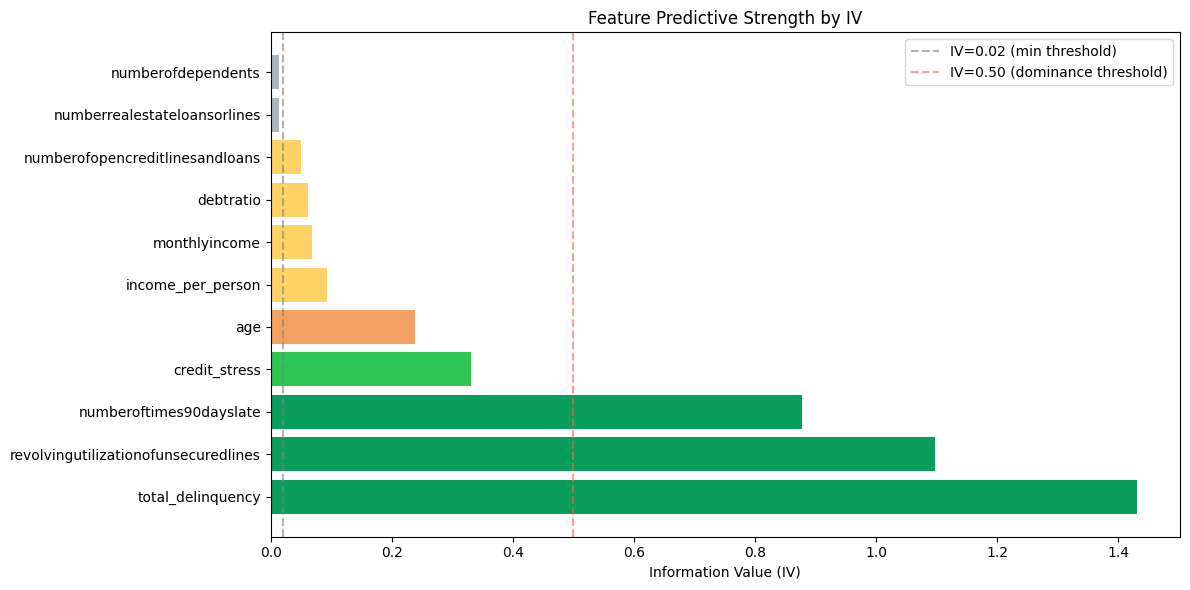

In [137]:
plt.figure(figsize=(12, 6))
strength_colors = {
    'Useless': '#adb5bd',
    'Weak': '#ffd166',
    'Medium': '#f4a261',
    'Strong': '#2dc653',
    'Very Strong (review)': '#0a9e5c',
}
bars = plt.barh(iv_summary['Feature'], iv_summary['IV'],
                color=[strength_colors[s] for s in iv_summary['Predictive Strength']])
plt.axvline(x=0.02,  color='grey',   linestyle='--', alpha=0.6, label='IV=0.02 (min threshold)')
plt.axvline(x=0.5,   color='tomato', linestyle='--', alpha=0.6, label='IV=0.50 (dominance threshold)')
plt.xlabel('Information Value (IV)')
plt.title('Feature Predictive Strength by IV')
plt.legend()
plt.tight_layout()
plt.show()

In [138]:
elected_features = iv_summary[
    (iv_summary['IV'] >= 0.02)
    & (iv_summary['Monotonic'] == True)
    & (iv_summary['IV'] <= 1.5)   # guard against data-leaking features
]['Feature'].tolist()

print(f"\nSelected features ({len(selected_features)}): {selected_features}")



Selected features (5): ['total_delinquency', 'revolvingutilizationofunsecuredlines', 'numberoftimes90dayslate', 'age', 'income_per_person']


In [139]:
X_train_woe_transformed = X_train.copy()
X_test_woe_transformed  = X_test.copy()


In [140]:
for feature in selected_features:
    result    = next(r for r in woe_results if r['feature'] == feature)
    edges     = bin_edges_dict[feature]

    X_train_woe_transformed = apply_woe_transformation(
        X_train_woe_transformed, feature, edges, result['woe_table']
    )
    X_test_woe_transformed = apply_woe_transformation(
        X_test_woe_transformed, feature, edges, result['woe_table']
    )

In [141]:
woe_columns = [f"{f}_woe" for f in selected_features]

train_missing = X_train_woe_transformed[woe_columns].isnull().sum().sum()
test_missing  = X_test_woe_transformed[woe_columns].isnull().sum().sum()

assert train_missing == 0, f"Train WOE has {train_missing} missing values"
assert test_missing  == 0, f"Test WOE has {test_missing} missing values"

print("\n✅ WOE Transformation Successful — No Missing Values")
print(f"\nFinal WOE feature columns ({len(woe_columns)}):")
print(woe_columns)
print("\nSample (first 5 rows):")
print(X_train_woe_transformed[woe_columns].head().round(4))
print("\nSummary statistics:")
print(X_train_woe_transformed[woe_columns].describe().round(4))


✅ WOE Transformation Successful — No Missing Values

Final WOE feature columns (5):
['total_delinquency_woe', 'revolvingutilizationofunsecuredlines_woe', 'numberoftimes90dayslate_woe', 'age_woe', 'income_per_person_woe']

Sample (first 5 rows):
        total_delinquency_woe  revolvingutilizationofunsecuredlines_woe  \
57836                  0.9328                                    0.8038   
132895                 0.9328                                    1.3406   
27981                  0.9328                                    0.8038   
37852                  0.9328                                   -1.3889   
103813                 0.9328                                    0.8038   

        numberoftimes90dayslate_woe  age_woe  income_per_person_woe  
57836                        0.3929   0.3792                -0.4592  
132895                       0.3929   1.0422                 0.1197  
27981                        0.3929  -0.5320                -0.4592  
37852                  

# PHASE 8 — Logistic Regression Credit Scorecard Model

In [142]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [143]:
X_train_model = X_train_woe_transformed[woe_columns]
X_test_model  = X_test_woe_transformed[woe_columns]

In [144]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_model)
X_test_scaled  = scaler.transform(X_test_model)

In [145]:
lr_model = LogisticRegression(
    C=0.1,
    class_weight='balanced',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000,
                   random_state=42)

In [146]:
coef_df = pd.DataFrame({
    'Feature':     woe_columns,
    'Coefficient': lr_model.coef_[0],
}).sort_values('Coefficient', ascending=False)

print("\n" + "="*60)
print("LOGISTIC REGRESSION COEFFICIENTS")
print("="*60)
print(coef_df.to_string(index=False))
print(f"\nIntercept: {lr_model.intercept_[0]:.4f}")
print("""
Interpretation:
  Positive coefficient → higher WOE → more good borrowers → LOWER risk
  Negative coefficient → higher WOE → more bad borrowers  → HIGHER risk
  WOE is defined as log(dist_good / dist_bad), so a positive WOE bin
  already means that bin has proportionally more good borrowers.
  The logistic regression learns the weight each feature's WOE contributes
  to the final log-odds of DEFAULT (class 1).
""")


LOGISTIC REGRESSION COEFFICIENTS
                                 Feature  Coefficient
                   income_per_person_woe    -0.076264
             numberoftimes90dayslate_woe    -0.153571
                                 age_woe    -0.250578
revolvingutilizationofunsecuredlines_woe    -0.663910
                   total_delinquency_woe    -0.664456

Intercept: -0.7602

Interpretation:
  Positive coefficient → higher WOE → more good borrowers → LOWER risk
  Negative coefficient → higher WOE → more bad borrowers  → HIGHER risk
  WOE is defined as log(dist_good / dist_bad), so a positive WOE bin
  already means that bin has proportionally more good borrowers.
  The logistic regression learns the weight each feature's WOE contributes
  to the final log-odds of DEFAULT (class 1).



# PHASE 9 — Scorecard Scaling


In [147]:
BASE_SCORE = 600
BASE_ODDS  = 50       # good:bad odds at base score
PDO        = 20       # score points needed to double the odds

FACTOR = PDO / np.log(2)
OFFSET = BASE_SCORE - FACTOR * np.log(BASE_ODDS)

print(f"\nScorecard scaling parameters:")
print(f"  Base Score : {BASE_SCORE}")
print(f"  Base Odds  : {BASE_ODDS}:1")
print(f"  PDO        : {PDO}")
print(f"  Factor     : {FACTOR:.4f}")
print(f"  Offset     : {OFFSET:.4f}")



Scorecard scaling parameters:
  Base Score : 600
  Base Odds  : 50:1
  PDO        : 20
  Factor     : 28.8539
  Offset     : 487.1229


In [148]:
scorecard_rows = []

for i, feature in enumerate(selected_features):
    result    = next(r for r in woe_results if r['feature'] == feature)
    woe_table = result['woe_table']

    # The scaled coefficient maps to the original WOE scale via scaler std
    # scaler was fit on WOE columns — recover original coefficient magnitude
    coef_scaled = lr_model.coef_[0][i]
    woe_std     = scaler.scale_[i]
    coef_orig   = coef_scaled / woe_std          # back to WOE-space coefficient

    intercept_share = lr_model.intercept_[0] / len(selected_features)

    for bin_label, row in woe_table.iterrows():
        woe_val = row['woe']
        points  = -(coef_orig * woe_val + intercept_share) * FACTOR
        scorecard_rows.append({
            'Feature':    feature,
            'Bin':        str(bin_label),
            'WOE':        round(woe_val, 4),
            'Bad Rate':   f"{row['bad']/row['total']*100:.1f}%",
            'Points':     round(points, 1),
        })

scorecard_df = pd.DataFrame(scorecard_rows)

print("\n" + "="*70)
print("CREDIT SCORECARD TABLE")
print("="*70)
for feat in selected_features:
    subset = scorecard_df[scorecard_df['Feature'] == feat]
    print(f"\n  {feat.upper()}")
    print(f"  {'Bin':<30} {'WOE':>8} {'Bad Rate':>10} {'Points':>8}")
    print(f"  {'-'*60}")
    for _, r in subset.iterrows():
        print(f"  {r['Bin']:<30} {r['WOE']:>8.4f} {r['Bad Rate']:>10} {r['Points']:>8.1f}")



CREDIT SCORECARD TABLE

  TOTAL_DELINQUENCY
  Bin                                 WOE   Bad Rate   Points
  ------------------------------------------------------------
  (-1.001, 0.0]                    0.9328       2.7%     23.5
  (0.0, 1.0]                      -0.6586      12.2%     -9.1
  (1.0, 2.0]                      -1.4795      23.9%    -26.0
  (2.0, 5.0]                      -2.2331      40.1%    -41.4
  (5.0, 10.0]                     -3.0000      59.9%    -57.2

  REVOLVINGUTILIZATIONOFUNSECUREDLINES
  Bin                                 WOE   Bad Rate   Points
  ------------------------------------------------------------
  (-0.002, 0.1]                    1.3406       1.8%     30.1
  (0.1, 0.3]                       0.8038       3.1%     19.8
  (0.3, 0.5]                       0.1615       5.7%      7.5
  (0.5, 0.7]                      -0.3963       9.6%     -3.2
  (0.7, 0.9]                      -0.9152      15.2%    -13.1
  (0.9, inf]                      -1.3889    

# PHASE 10 — Model Evaluation

In [149]:
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

y_train_prob = lr_model.predict_proba(X_train_scaled)[:, 1]
y_test_prob  = lr_model.predict_proba(X_test_scaled)[:, 1]

In [150]:
def prob_to_score(prob, factor=FACTOR, offset=OFFSET):
    """Convert PD probability to scorecard points. Clips to avoid log(0)."""
    prob   = np.clip(prob, 1e-6, 1 - 1e-6)
    odds   = (1 - prob) / prob          # good:bad odds
    return offset + factor * np.log(odds)

train_scores = prob_to_score(y_train_prob)
test_scores  = prob_to_score(y_test_prob)

In [151]:
train_auc = roc_auc_score(y_train, y_train_prob)
test_auc  = roc_auc_score(y_test,  y_test_prob)
print(f"\n{'='*60}")
print(f"MODEL EVALUATION METRICS")
print(f"{'='*60}")
print(f"  AUC  — Train : {train_auc:.4f}")
print(f"  AUC  — Test  : {test_auc:.4f}")
print("  (AUC > 0.75 is acceptable for credit risk; >0.80 is good)")


MODEL EVALUATION METRICS
  AUC  — Train : 0.8526
  AUC  — Test  : 0.8600
  (AUC > 0.75 is acceptable for credit risk; >0.80 is good)


In [152]:
def ks_statistic(y_true, y_prob):
    """
    KS = max separation between cumulative Good and Bad distributions.
    In lending: KS > 40 is strong, 20–40 is acceptable.
    """
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ks = np.max(tpr - fpr)
    return ks

train_ks = ks_statistic(y_train, y_train_prob)
test_ks  = ks_statistic(y_test,  y_test_prob)
print(f"\n  KS   — Train : {train_ks:.4f}  ({train_ks*100:.1f})")
print(f"  KS   — Test  : {test_ks:.4f}  ({test_ks*100:.1f})")
print("  (KS > 0.40 → strong separation of good/bad borrowers)")


  KS   — Train : 0.5494  (54.9)
  KS   — Test  : 0.5635  (56.3)
  (KS > 0.40 → strong separation of good/bad borrowers)


In [153]:
y_test_pred = (y_test_prob >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_test_pred)
print(f"\n  Confusion Matrix (threshold=0.5):")
print(f"                Predicted Good  Predicted Bad")
print(f"  Actual Good       {cm[0,0]:>8}       {cm[0,1]:>8}")
print(f"  Actual Bad        {cm[1,0]:>8}       {cm[1,1]:>8}")
print(f"\n{classification_report(y_test, y_test_pred, target_names=['Good','Bad'])}")


  Confusion Matrix (threshold=0.5):
                Predicted Good  Predicted Bad
  Actual Good          22642           5353
  Actual Bad             498           1507

              precision    recall  f1-score   support

        Good       0.98      0.81      0.89     27995
         Bad       0.22      0.75      0.34      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.78      0.61     30000
weighted avg       0.93      0.80      0.85     30000



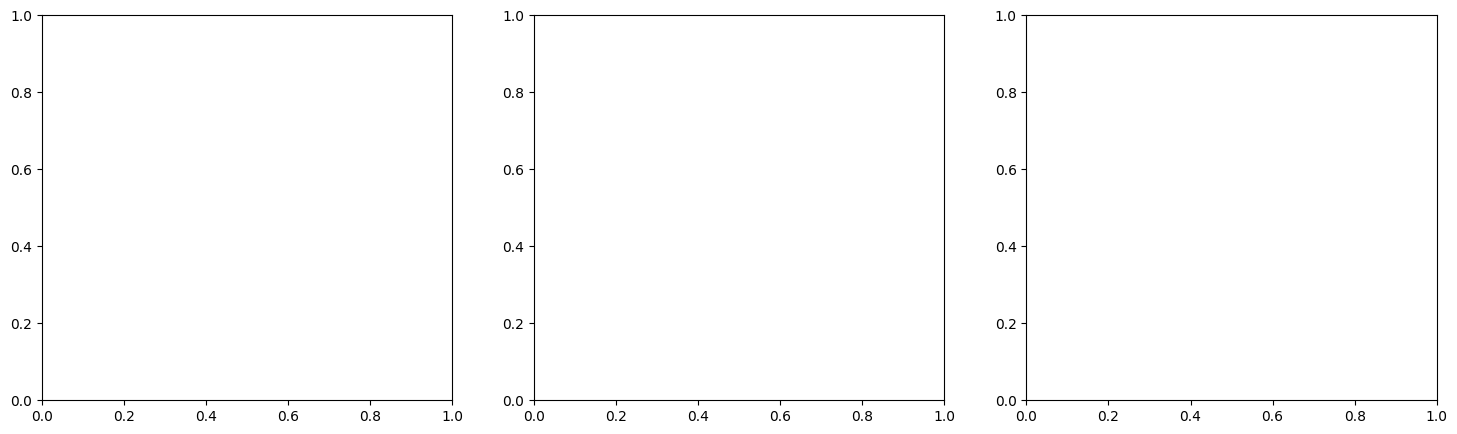

In [154]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

In [155]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {test_auc:.3f}')
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

In [156]:
fpr_s, tpr_s, _ = roc_curve(y_test, y_test_prob)
ks_idx = np.argmax(tpr_s - fpr_s)
axes[1].plot(fpr_s, tpr_s,       color='steelblue', lw=2, label='TPR (Cumul. Bads caught)')
axes[1].plot(fpr_s, fpr_s,       color='tomato',    lw=2, label='FPR (Cumul. Goods rejected)')
axes[1].axvline(fpr_s[ks_idx], color='green', linestyle='--',
                label=f'KS = {test_ks:.3f} at FPR={fpr_s[ks_idx]:.3f}')
axes[1].annotate(f'KS={test_ks:.3f}',
                 xy=(fpr_s[ks_idx], (tpr_s[ks_idx]+fpr_s[ks_idx])/2),
                 xytext=(fpr_s[ks_idx]+0.05, (tpr_s[ks_idx]+fpr_s[ks_idx])/2),
                 arrowprops=dict(arrowstyle='->', color='green'), color='green')
axes[1].set_xlabel('Population %')
axes[1].set_title('KS Separation Chart')
axes[1].legend(fontsize=8)

In [157]:
axes[2].hist(test_scores[y_test == 0], bins=40, alpha=0.6,
             color='steelblue', label='Good (0)', density=True)
axes[2].hist(test_scores[y_test == 1], bins=40, alpha=0.6,
             color='tomato', label='Bad (1)', density=True)
axes[2].set_xlabel('Credit Score')
axes[2].set_ylabel('Density')
axes[2].set_title('Score Distribution by Class')
axes[2].legend()

plt.suptitle('Model Evaluation Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>


GAINS & LIFT TABLE (Test Set — sorted by score descending)
 Decile   Total    Bads   Bad Rate   Cum Bads   Gains%    Lift
----------------------------------------------------------------------
      1    3000    1083      36.1%       1083    54.0%    5.40x
      2    3000     356      11.9%       1439    71.8%    3.59x
      3    3000     202       6.7%       1641    81.8%    2.73x
      4    3000     120       4.0%       1761    87.8%    2.20x
      5    3000      91       3.0%       1852    92.4%    1.85x
      6    3000      63       2.1%       1915    95.5%    1.59x
      7    3000      32       1.1%       1947    97.1%    1.39x
      8    3000      25       0.8%       1972    98.4%    1.23x
      9    3000      22       0.7%       1994    99.5%    1.11x
     10    3000      11       0.4%       2005   100.0%    1.00x


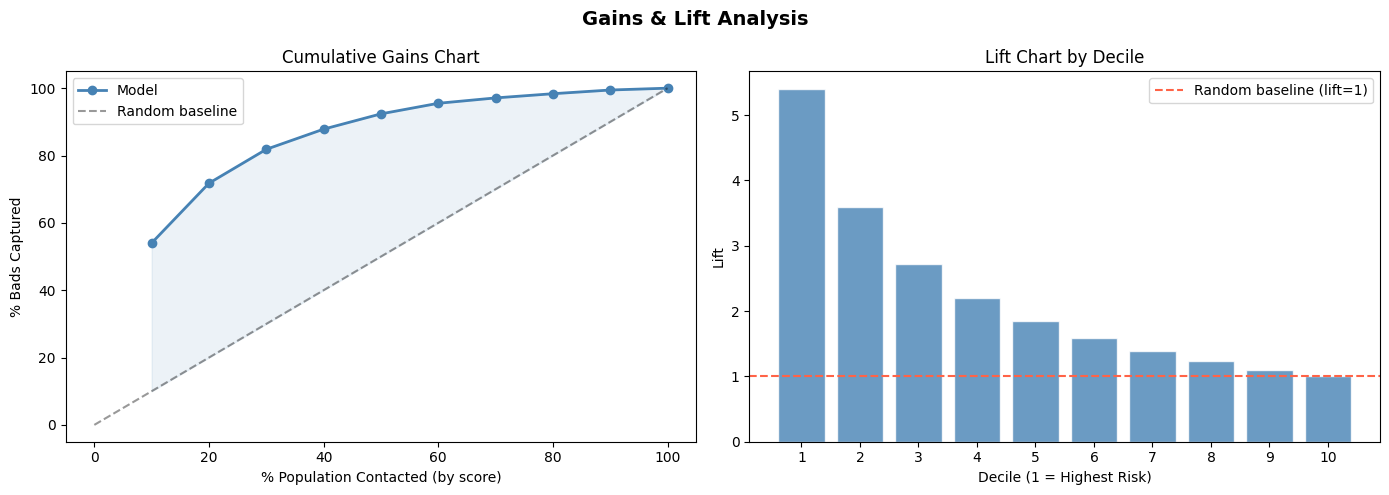

In [158]:

# ── Gains & Lift charts ───────────────────────────────────────────────────────
def gains_lift_table(y_true, y_prob, n_bins=10):
    """Build decile-level gains and lift table."""
    df_gl = pd.DataFrame({'y': y_true.values, 'prob': y_prob})
    df_gl = df_gl.sort_values('prob', ascending=False).reset_index(drop=True)
    df_gl['decile'] = pd.qcut(df_gl.index, q=n_bins, labels=range(1, n_bins+1))

    total_bad  = df_gl['y'].sum()
    total_good = len(df_gl) - total_bad

    table = df_gl.groupby('decile', observed=True).agg(
        total=('y', 'count'),
        bads=('y', 'sum')
    ).reset_index()
    table['goods']        = table['total'] - table['bads']
    table['bad_rate']     = table['bads']  / table['total']
    table['cum_bads']     = table['bads'].cumsum()
    table['cum_total']    = table['total'].cumsum()
    table['gains']        = table['cum_bads'] / total_bad * 100
    table['pct_pop']      = table['cum_total'] / len(df_gl) * 100
    table['lift']         = table['gains'] / table['pct_pop']
    return table

gl_table = gains_lift_table(y_test, y_test_prob)

print("\n" + "="*70)
print("GAINS & LIFT TABLE (Test Set — sorted by score descending)")
print("="*70)
print(f"{'Decile':>7} {'Total':>7} {'Bads':>7} {'Bad Rate':>10} "
      f"{'Cum Bads':>10} {'Gains%':>8} {'Lift':>7}")
print("-"*70)
for _, row in gl_table.iterrows():
    print(f"  {int(row['decile']):>5} {int(row['total']):>7} {int(row['bads']):>7} "
          f"{row['bad_rate']*100:>9.1f}% {int(row['cum_bads']):>10} "
          f"{row['gains']:>7.1f}% {row['lift']:>7.2f}x")

# Gains & Lift plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(gl_table['pct_pop'], gl_table['gains'],
             'o-', color='steelblue', lw=2, label='Model')
axes[0].plot([0, 100], [0, 100], 'k--', alpha=0.4, label='Random baseline')
axes[0].fill_between(gl_table['pct_pop'], gl_table['gains'],
                     gl_table['pct_pop'], alpha=0.1, color='steelblue')
axes[0].set_xlabel('% Population Contacted (by score)')
axes[0].set_ylabel('% Bads Captured')
axes[0].set_title('Cumulative Gains Chart')
axes[0].legend()

axes[1].bar(gl_table['decile'].astype(str), gl_table['lift'],
            color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axhline(y=1.0, color='tomato', linestyle='--', label='Random baseline (lift=1)')
axes[1].set_xlabel('Decile (1 = Highest Risk)')
axes[1].set_ylabel('Lift')
axes[1].set_title('Lift Chart by Decile')
axes[1].legend()

plt.suptitle('Gains & Lift Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# PHASE 11 — Lending Decision Strategy

In [159]:
APPROVE_THRESHOLD = float(np.percentile(test_scores, 70))
REVIEW_THRESHOLD  = float(np.percentile(test_scores, 40))

print(f"\n  Score range on test set  : {test_scores.min():.1f} -- {test_scores.max():.1f}")
print(f"  Derived thresholds (p70 / p40 of test scores):")
print(f"    APPROVE >= {APPROVE_THRESHOLD:.1f}")
print(f"    REVIEW   {REVIEW_THRESHOLD:.1f} -- {APPROVE_THRESHOLD:.1f}")
print(f"    REJECT  < {REVIEW_THRESHOLD:.1f}")



  Score range on test set  : 366.1 -- 551.0
  Derived thresholds (p70 / p40 of test scores):
    APPROVE >= 531.8
    REVIEW   510.4 -- 531.8
    REJECT  < 510.4


In [160]:
def assign_decision(score):
    if score >= APPROVE_THRESHOLD:
        return 'APPROVE'
    elif score >= REVIEW_THRESHOLD:
        return 'REVIEW'
    else:
        return 'REJECT'

In [161]:
decisions = pd.Series(test_scores, index=y_test.index).apply(assign_decision)
results_df = pd.DataFrame({
    'score':    test_scores,
    'decision': decisions.values,
    'actual':   y_test.values,
}, index=y_test.index)


In [162]:
print()
for band in ['APPROVE', 'REVIEW', 'REJECT']:
    subset = results_df[results_df['decision'] == band]
    n      = len(subset)
    pct    = n / len(results_df) * 100
    dr     = subset['actual'].mean() * 100 if n > 0 else 0.0
    print(f"  {band:<8}: {n:>6} borrowers ({pct:>5.1f}%)  |  "
          f"Default rate: {dr:>5.1f}%")

print(f"""
  Business interpretation:
  ─ APPROVE  band should have low default rate (<5%) for safe portfolio
  ─ REVIEW   band goes to underwriters for manual assessment
  ─ REJECT   band has highest default concentration; declining protects the book

  Trade-off: raising APPROVE threshold → lower default rate but fewer loans approved
             lowering APPROVE threshold → more revenue but higher credit losses
""")



  APPROVE :   9212 borrowers ( 30.7%)  |  Default rate:   0.7%
  REVIEW  :   8803 borrowers ( 29.3%)  |  Default rate:   2.0%
  REJECT  :  11985 borrowers ( 40.0%)  |  Default rate:  14.7%

  Business interpretation:
  ─ APPROVE  band should have low default rate (<5%) for safe portfolio
  ─ REVIEW   band goes to underwriters for manual assessment
  ─ REJECT   band has highest default concentration; declining protects the book
  
  Trade-off: raising APPROVE threshold → lower default rate but fewer loans approved
             lowering APPROVE threshold → more revenue but higher credit losses



# PHASE 12 — Population Stability Index (PSI) Monitoring

In [163]:
def compute_psi(expected_scores, actual_scores, n_bins=10):
    """
    PSI measures how much the score distribution has shifted between
    two populations (e.g. training vs new applicants over time).

    PSI < 0.10 → stable      (no action needed)
    PSI 0.10–0.25 → warning  (investigate)
    PSI > 0.25 → unstable    (model likely needs retraining)
    """
    min_score = min(expected_scores.min(), actual_scores.min())
    max_score = max(expected_scores.max(), actual_scores.max())
    bins = np.linspace(min_score, max_score, n_bins + 1)

    expected_pct = np.histogram(expected_scores, bins=bins)[0] / len(expected_scores)
    actual_pct   = np.histogram(actual_scores,   bins=bins)[0] / len(actual_scores)

    # Avoid log(0)
    expected_pct = np.where(expected_pct == 0, 1e-6, expected_pct)
    actual_pct   = np.where(actual_pct   == 0, 1e-6, actual_pct)

    psi_values = (actual_pct - expected_pct) * np.log(actual_pct / expected_pct)
    psi_total  = psi_values.sum()

    psi_df = pd.DataFrame({
        'Bin':          [f"[{bins[i]:.0f}, {bins[i+1]:.0f})" for i in range(n_bins)],
        'Expected %':   (expected_pct * 100).round(2),
        'Actual %':     (actual_pct   * 100).round(2),
        'PSI':          psi_values.round(4),
    })
    return psi_total, psi_df


In [164]:
psi_total, psi_table = compute_psi(train_scores, test_scores)

print("\n" + "="*60)
print("POPULATION STABILITY INDEX (PSI) — Train vs Test")
print("="*60)
print(psi_table.to_string(index=False))
print(f"\n  Total PSI : {psi_total:.4f}")
if psi_total < 0.10:
    print("  ✅ Stable — score distribution has not shifted significantly")
elif psi_total < 0.25:
    print("  ⚠ Warning — moderate shift detected, monitor closely")
else:
    print("  ❗ Unstable — significant shift, consider model recalibration")



POPULATION STABILITY INDEX (PSI) — Train vs Test
       Bin  Expected %  Actual %    PSI
[366, 385)        0.69      0.71 0.0000
[385, 403)        1.37      1.30 0.0000
[403, 422)        1.76      1.74 0.0000
[422, 440)        2.69      2.70 0.0000
[440, 459)        3.88      3.83 0.0000
[459, 477)        6.48      6.54 0.0000
[477, 496)       11.60     11.73 0.0000
[496, 514)       13.78     13.76 0.0000
[514, 533)       27.81     28.15 0.0000
[533, 551)       29.97     29.55 0.0001

  Total PSI : 0.0002
  ✅ Stable — score distribution has not shifted significantly



DEFAULT RATE BY SCORE BAND
score_band  Count  Defaults  Default Rate %  Population %
   366-397    494       298            60.3           1.6
   397-428    956       406            42.5           3.2
   428-459   1633       393            24.1           5.4
   459-489   4204       434            10.3          14.0
   489-520   7502       315             4.2          25.0
   520-551  15211       159             1.0          50.7


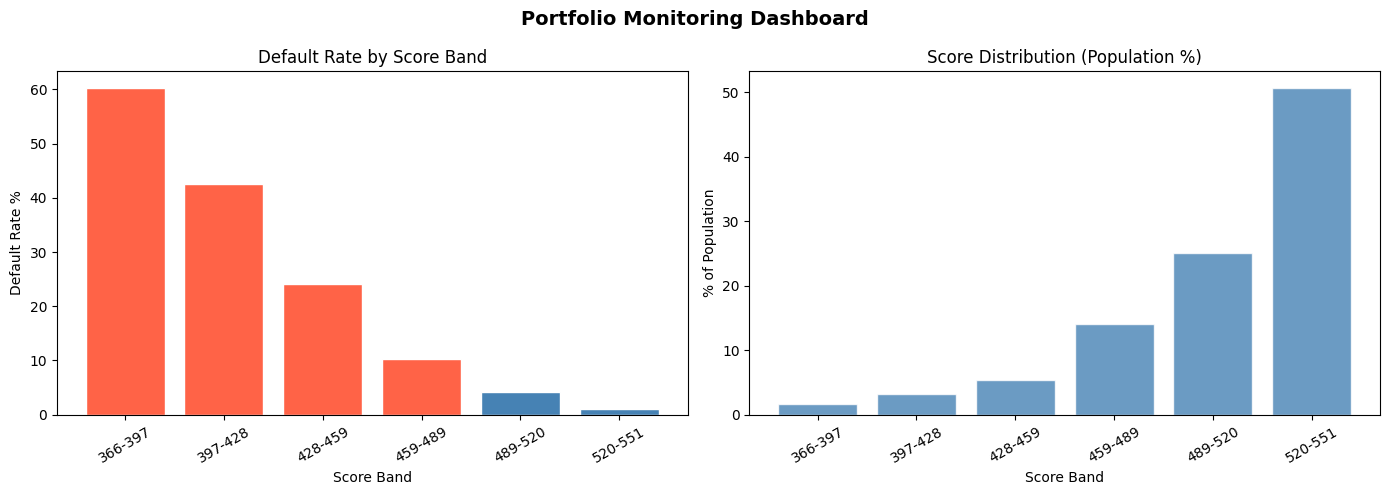

In [165]:
print("\n" + "="*60)
print("DEFAULT RATE BY SCORE BAND")
print("="*60)
# FIX: hardcoded bin edges [550,580,610,640,670] were above the actual max score
# (~551), so max+1 < 670 and pd.cut raised: ValueError: bins must increase monotonically.
# We now build 6 equal-width bands from the actual score min/max.
band_edges  = np.linspace(test_scores.min(), test_scores.max(), 7)
band_labels = [f"{band_edges[i]:.0f}-{band_edges[i+1]:.0f}" for i in range(6)]
score_bands = pd.cut(test_scores, bins=band_edges, labels=band_labels, include_lowest=True)

monitor_df = pd.DataFrame({
    'score_band': score_bands,
    'actual':     y_test.values,
})
band_stats = monitor_df.groupby('score_band', observed=True).agg(
    Count=('actual', 'count'),
    Defaults=('actual', 'sum'),
).reset_index()
band_stats['Default Rate %'] = (band_stats['Defaults'] / band_stats['Count'] * 100).round(1)
band_stats['Population %']   = (band_stats['Count'] / len(monitor_df) * 100).round(1)
print(band_stats.to_string(index=False))

# Monitoring chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(band_stats['score_band'].astype(str),
            band_stats['Default Rate %'],
            color=['tomato' if dr > 10 else 'steelblue'
                   for dr in band_stats['Default Rate %']],
            edgecolor='white')
axes[0].set_xlabel('Score Band')
axes[0].set_ylabel('Default Rate %')
axes[0].set_title('Default Rate by Score Band')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(band_stats['score_band'].astype(str),
            band_stats['Population %'],
            color='steelblue', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Score Band')
axes[1].set_ylabel('% of Population')
axes[1].set_title('Score Distribution (Population %)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Portfolio Monitoring Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# PHASE 13 — Example Borrower Scoring Workflow

In [166]:

print("\n" + "="*60)
print("EXAMPLE BORROWER SCORING WORKFLOW")
print("="*60)

# Simulate two borrowers
borrower_A = {
    'revolvingutilizationofunsecuredlines': 0.05,   # low utilization — low risk
    'age': 52,
    'numberoftime30-59dayspastduenotworse': 0,
    'debtratio': 0.25,
    'monthlyincome': 8000,
    'numberofopencreditlinesandloans': 10,
    'numberoftimes90dayslate': 0,
    'numberrealestateloansorlines': 1,
    'numberoftime60-89dayspastduenotworse': 0,
    'numberofdependents': 1,
    'monthlyincome_missing': 0,
    'numberofdependents_missing': 0,
}

borrower_B = {
    'revolvingutilizationofunsecuredlines': 0.92,   # high utilization — high risk
    'age': 24,
    'numberoftime30-59dayspastduenotworse': 3,
    'debtratio': 0.85,
    'monthlyincome': 2200,
    'numberofopencreditlinesandloans': 4,
    'numberoftimes90dayslate': 2,
    'numberrealestateloansorlines': 0,
    'numberoftime60-89dayspastduenotworse': 1,
    'numberofdependents': 3,
    'monthlyincome_missing': 0,
    'numberofdependents_missing': 0,
}

def score_borrower(borrower_dict, selected_features, woe_results,
                   bin_edges_dict, scaler, lr_model, factor=FACTOR, offset=OFFSET):
    """Score a single borrower end-to-end."""
    row = pd.DataFrame([borrower_dict])

    # Feature engineering
    row['total_delinquency'] = (
        row['numberoftime30-59dayspastduenotworse']
        + row['numberoftime60-89dayspastduenotworse']
        + row['numberoftimes90dayslate']
    )
    row['income_per_person'] = row['monthlyincome'] / (row['numberofdependents'] + 1)
    row['credit_stress']     = row['revolvingutilizationofunsecuredlines'] * row['debtratio']

    # Outlier cap using training bounds (approximate for demo)
    for col in num_cols_eng:
        if col in row.columns and col in outlier_bounds:
            lo, hi = outlier_bounds[col]
            row[col] = row[col].clip(lo, hi)

    # WOE transformation
    for feature in selected_features:
        result = next(r for r in woe_results if r['feature'] == feature)
        edges  = bin_edges_dict[feature]
        row    = apply_woe_transformation(row, feature, edges, result['woe_table'])

    woe_cols = [f"{f}_woe" for f in selected_features]
    X        = row[woe_cols].values
    X_scaled = scaler.transform(X)

    pd_prob  = lr_model.predict_proba(X_scaled)[0, 1]
    score    = offset + factor * np.log(np.clip((1 - pd_prob) / pd_prob, 1e-6, 1e6))
    decision = assign_decision(score)

    return pd_prob, score, decision, row[woe_cols].iloc[0]

for name, borrower in [('Borrower A (Low Risk)', borrower_A),
                        ('Borrower B (High Risk)', borrower_B)]:
    pd_prob, score, decision, woe_vals = score_borrower(
        borrower, selected_features, woe_results,
        bin_edges_dict, scaler, lr_model
    )
    print(f"\n  {name}")
    print(f"  {'─'*45}")
    print(f"  PD Probability : {pd_prob:.4f}  ({pd_prob*100:.2f}%)")
    print(f"  Credit Score   : {score:.1f}")
    print(f"  Decision       : {decision}")
    print(f"\n  WOE feature contributions:")
    for feat, val in woe_vals.items():
        print(f"    {feat:<45}: {val:>8.4f}")

print("\n" + "="*60)
print("PIPELINE COMPLETE")
print("="*60)


EXAMPLE BORROWER SCORING WORKFLOW

  Borrower A (Low Risk)
  ─────────────────────────────────────────────
  PD Probability : 0.1694  (16.94%)
  Credit Score   : 533.0
  Decision       : APPROVE

  WOE feature contributions:
    total_delinquency_woe                        :   0.9328
    revolvingutilizationofunsecuredlines_woe     :   1.3406
    numberoftimes90dayslate_woe                  :   0.3929
    age_woe                                      :  -0.1402
    income_per_person_woe                        :   0.1197

  Borrower B (High Risk)
  ─────────────────────────────────────────────
  PD Probability : 0.9837  (98.37%)
  Credit Score   : 368.8
  Decision       : REJECT

  WOE feature contributions:
    total_delinquency_woe                        :  -3.0000
    revolvingutilizationofunsecuredlines_woe     :  -1.3889
    numberoftimes90dayslate_woe                  :  -2.6171
    age_woe                                      :  -0.5448
    income_per_person_woe                  